# 汉文 ISAC 测量 PDP 分析

| 文件 | 格式 | 处理方式 |
|------|------|----------|
| `test1.bin` | 单IQ/帧（FPGA IQ平均） | 直接匹配滤波 → PDP |
| `test2.bin` | 15IQ/帧（连续ZC序列） | 滑动相关 → CIR平均 → PDP |

## Section 1: Setup & Imports

In [1]:
import sys
import math
from pathlib import Path

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

PROJECT_ROOT = Path().resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.io.bin_reader_luoyang import LuoyangBinReader
from src.io.bin_read import _load_frames, _parse_iq, _sliding_correlate
from src.io.bin_read import _S_MATCHED, BW_HZ, U, _N_FFT

matplotlib.rcParams.update({'font.family': 'Times New Roman', 'font.size': 12})
%matplotlib inline

DATA_DIR = Path('/mnt/win_data/data_mea/data_save/Mea_data/Hanwen_04_ISAC')
TEST1 = DATA_DIR / '接收数据帧_20260417103937876_test1.bin'
TEST2 = DATA_DIR / '接收数据帧_20260421154726651_test2.bin'

delay_ns = np.arange(U) / BW_HZ * 1e9  # 时延轴 (ns)

print(f'Project root : {PROJECT_ROOT}')
print(f'U={U}, BW={BW_HZ/1e6:.0f} MHz')
print(f'test1 exists : {TEST1.exists()}  ({TEST1.stat().st_size/1e3:.0f} KB)')
print(f'test2 exists : {TEST2.exists()}  ({TEST2.stat().st_size/1e3:.0f} KB)')

Project root : /home/guo/project/chan_meas
U=1024, BW=50 MHz
test1 exists : True  (83 KB)
test2 exists : True  (979 KB)


## Section 2: test1 — FPGA IQ 平均版本

帧格式与 B2B 相同（`FRAME_LEN=4132`，单 IQ/帧）。  
直接用 `_load_frames` → `_parse_iq` → `_sliding_correlate` 得到 CIR，画 PDP。

In [2]:
frames1 = _load_frames(TEST1)
iq1     = _parse_iq(frames1)
cir1    = _sliding_correlate(iq1)   # (n_frames, U) complex64
del frames1, iq1

n_frames1 = cir1.shape[0]
print(f'test1: {n_frames1} frames, CIR shape = {cir1.shape}')

test1: 20 frames, CIR shape = (20, 1024)


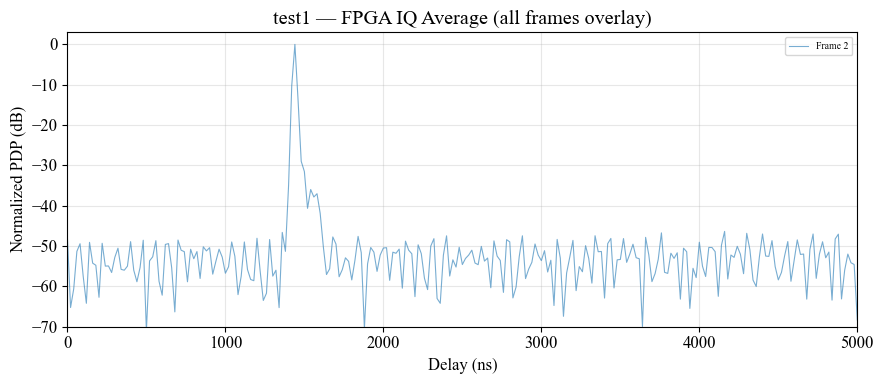

In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
for i in [2]: # range(n_frames1)
    pdp = np.abs(cir1[i]) ** 2
    pdp_db = 10 * np.log10(pdp + 1e-30)
    pdp_db -= pdp_db.max()
    ax.plot(delay_ns, pdp_db, lw=0.8, alpha=0.6, label=f'Frame {i}')

ax.set_xlabel('Delay (ns)')
ax.set_ylabel('Normalized PDP (dB)')
ax.set_title('test1 — FPGA IQ Average (all frames overlay)')
ax.set_xlim([0, 5000])
ax.set_ylim([-70, 3])
ax.grid(True, alpha=0.3)
if n_frames1 <= 20:
    ax.legend(fontsize=7, ncol=4, loc='upper right')
fig.tight_layout()
plt.show()

### 各帧 peak delay 与 SNR

In [4]:
print(f'  Frame  Peak_bin  Peak_delay(ns)  SNR(dB)')
print('-' * 46)
for i in range(n_frames1):
    pdp = np.abs(cir1[i]) ** 2
    pb  = int(np.argmax(pdp))
    pd_ns = pb * 1e9 / BW_HZ
    mask = np.abs(np.arange(U) - pb) > 50
    nf   = np.median(pdp[mask]) if mask.sum() > 10 else pdp.min()
    snr  = 10 * np.log10(pdp[pb] / max(nf, 1e-30))
    print(f'  {i:5d}  {pb:8d}  {pd_ns:14.1f}  {snr:8.2f}')

  Frame  Peak_bin  Peak_delay(ns)  SNR(dB)
----------------------------------------------
      0        72          1440.0     53.87
      1        72          1440.0     53.92
      2        72          1440.0     54.00
      3        72          1440.0     54.03
      4        72          1440.0     53.87
      5        72          1440.0     53.86
      6        73          1460.0     54.02
      7        73          1460.0     53.95
      8        73          1460.0     54.14
      9        73          1460.0     54.17
     10        72          1440.0     54.07
     11        72          1440.0     53.97
     12        72          1440.0     53.85
     13        72          1440.0     53.91
     14        72          1440.0     53.91
     15        73          1460.0     53.98
     16        73          1460.0     54.14
     17        72          1440.0     53.89
     18        72          1440.0     53.81
     19        72          1440.0     53.78


## Section 3: test2 — 连续 15 个 ZC 序列版本

帧格式与武汉数据相同（`FRAME_LEN=61476`，15 IQ/帧）。  
处理方式：`correlate_long` → (15, U) CIR 矩阵 → 跳过第1个 → 平均剩余 14 个 CIR → PDP。

In [5]:
def correlate_long(iq_long: np.ndarray) -> np.ndarray:
    """15*U 长序列滑动匹配滤波 → (15, U) complex64 CIR.

    线性互相关，去掉前 U-1 边界点，reshape (15, U)，除以 U 归一化。
    """
    N = len(iq_long)
    n_fft_long = 1 << math.ceil(math.log2(N + U))
    x   = (iq_long - iq_long.mean()).astype(np.complex64)
    X   = np.fft.fft(x, n=n_fft_long)
    S_f = np.fft.fft(_S_MATCHED, n=n_fft_long)
    corr  = np.fft.ifft(X * S_f)
    valid = corr[U - 1 : U - 1 + N]
    return (valid.reshape(15, U) / U).astype(np.complex64)

In [6]:
reader  = LuoyangBinReader()
iq2_all = reader.read_iq_sequences(TEST2)   # (n_frames, 15, U) complex64
n_frames2 = iq2_all.shape[0]
print(f'test2: {n_frames2} frames, IQ shape = {iq2_all.shape}')

# 每帧：滑动相关 → (15, U) CIRs → 跳过第1个 → 平均 → (U,) CIR
cir2 = np.zeros((n_frames2, U), dtype=np.complex64)
for i in range(n_frames2):
    iq_long  = iq2_all[i].reshape(-1)   # (15*U,)
    cirs_all = correlate_long(iq_long)  # (15, U)
    cir2[i]  = cirs_all[1:].mean(axis=0)  # 跳过 idx=0，平均剩余 14 个

print(f'CIR2 shape = {cir2.shape}')

test2: 15 frames, IQ shape = (15, 15, 1024)
CIR2 shape = (15, 1024)


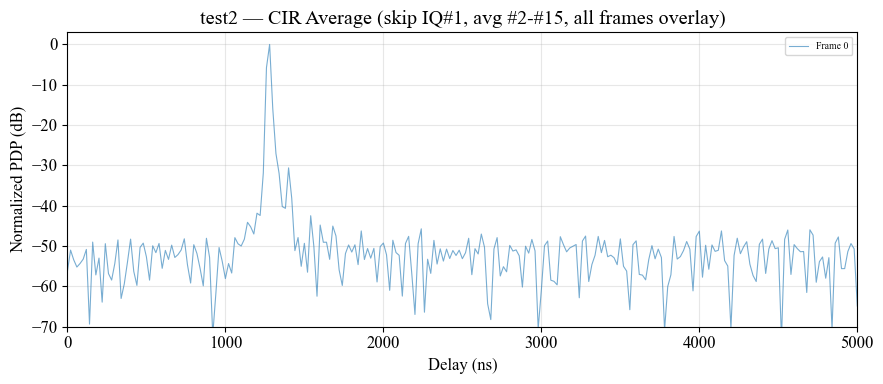

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))

for i in [0]: # range(n_frames2)
    pdp = np.abs(cir2[i]) ** 2
    pdp_db = 10 * np.log10(pdp + 1e-30)
    pdp_db -= pdp_db.max()
    ax.plot(delay_ns, pdp_db, lw=0.8, alpha=0.6, label=f'Frame {i}')

ax.set_xlabel('Delay (ns)')
ax.set_ylabel('Normalized PDP (dB)')
ax.set_title('test2 — CIR Average (skip IQ#1, avg #2-#15, all frames overlay)')
ax.set_xlim([0, 5000])
ax.set_ylim([-70, 3])
ax.grid(True, alpha=0.3)
if n_frames2 <= 20:
    ax.legend(fontsize=7, ncol=4, loc='upper right')
fig.tight_layout()
plt.show()

### 各帧 peak delay 与 SNR

In [8]:
print(f'  Frame  Peak_bin  Peak_delay(ns)  SNR(dB)')
print('-' * 46)
for i in range(n_frames2):
    pdp = np.abs(cir2[i]) ** 2
    pb  = int(np.argmax(pdp))
    pd_ns = pb * 1e9 / BW_HZ
    mask = np.abs(np.arange(U) - pb) > 50
    nf   = np.median(pdp[mask]) if mask.sum() > 10 else pdp.min()
    snr  = 10 * np.log10(pdp[pb] / max(nf, 1e-30))
    print(f'  {i:5d}  {pb:8d}  {pd_ns:14.1f}  {snr:8.2f}')

  Frame  Peak_bin  Peak_delay(ns)  SNR(dB)
----------------------------------------------
      0        64          1280.0     53.23
      1        64          1280.0     52.59
      2        63          1260.0     52.25
      3        63          1260.0     51.13
      4        64          1280.0     51.47
      5        63          1260.0     50.79
      6        62          1240.0     51.03
      7        63          1260.0     51.29
      8        64          1280.0     51.88
      9        64          1280.0     52.18
     10        64          1280.0     51.95
     11        64          1280.0     51.77
     12        64          1280.0     50.95
     13        64          1280.0     50.76
     14        64          1280.0     51.12


## Section 4: test2 — IQ 域平均后相关（M = 2, 3, 5, 13, 15）

对 test2 选定帧（`num_pdp`）的 15 个 IQ：跳过第1个，按 M 取子集 → **复数平均** → **复制三次** → 匹配滤波 → CIR → PDP。

> `num_pdp` 可调（0 ~ n_frames2-1），选择分析哪一帧。

In [9]:
num_pdp = 0  # ← 可调，选择分析第几帧（0 ~ n_frames2-1）

# IQ 子集：M 为末尾 IQ 的1-indexed编号（跳过第0个，从第2个开始）
# 与武汉 notebook 命名一致：M=5 → 用 #2~#5 → 4个IQ → indices [1,2,3,4]
SUBSETS_IQ = {
    'M=2':  [1],               # 只用第2个     → 1个IQ
    'M=3':  list(range(1, 3)), # 第2-3个       → 2个IQ
    'M=5':  list(range(1, 5)), # 第2-5个       → 4个IQ
    'M=13': list(range(1, 13)),# 第2-13个      → 12个IQ
    'M=15': list(range(1, 15)),# 第2-15个      → 14个IQ
}


def correlate_single(iq_seq: np.ndarray) -> np.ndarray:
    """单个 IQ 块 (U,) → CIR (U,)：DC去除 → tile×3 → 匹配滤波."""
    x = (iq_seq - iq_seq.mean()).astype(np.complex64)
    ext = np.tile(x, 3)
    F   = np.fft.fft(ext, n=_N_FFT)
    S_f = np.fft.fft(_S_MATCHED, n=_N_FFT)
    corr = np.fft.ifft(F * S_f)
    return (corr[2 * U - 1 : 3 * U - 1] / U).astype(np.complex64)


# 计算各子集 CIR
iq_frame = iq2_all[num_pdp]  # (15, U)，选定帧

cir_iq_avg = {}
for name, idx in SUBSETS_IQ.items():
    iq_avg = iq_frame[idx, :].mean(axis=0)   # 复数平均 → (U,)
    cir_iq_avg[name] = correlate_single(iq_avg)

print(f'分析帧: {num_pdp}  (共 {n_frames2} 帧)')
for name, idx in SUBSETS_IQ.items():
    print(f'  {name}: indices={idx[:3]}{"..." if len(idx)>3 else ""}  共{len(idx)}个IQ')

分析帧: 0  (共 15 帧)
  M=2: indices=[1]  共1个IQ
  M=3: indices=[1, 2]  共2个IQ
  M=5: indices=[1, 2, 3]...  共4个IQ
  M=13: indices=[1, 2, 3]...  共12个IQ
  M=15: indices=[1, 2, 3]...  共14个IQ


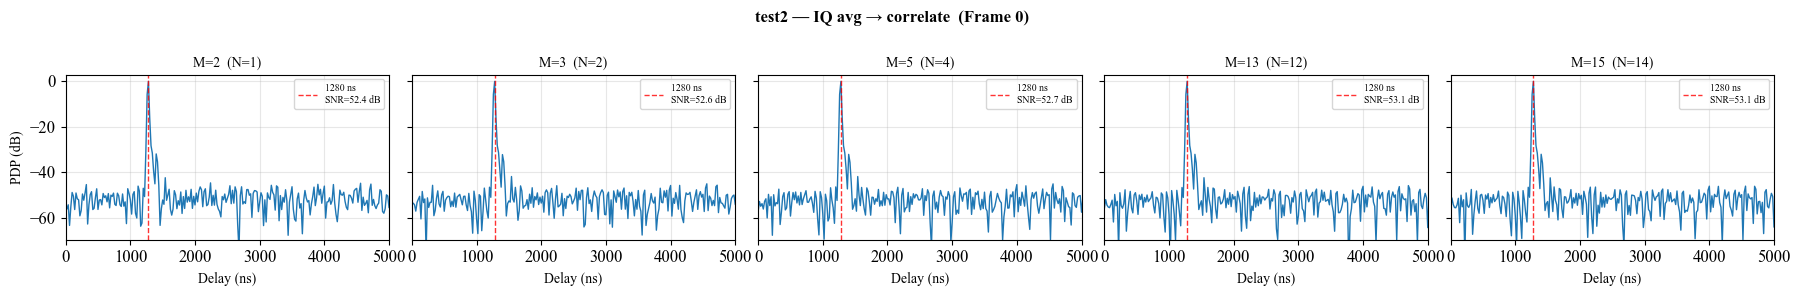

In [10]:
fig, axes = plt.subplots(1, 5, figsize=(18, 3), sharey=True)
fig.suptitle(f'test2 — IQ avg → correlate  (Frame {num_pdp})', fontsize=12, fontweight='bold')

for ax, (name, idx) in zip(axes, SUBSETS_IQ.items()):
    cir  = cir_iq_avg[name]
    pdp  = np.abs(cir) ** 2
    pdp_db = 10 * np.log10(pdp + 1e-30)
    pdp_db -= pdp_db.max()

    peak_bin   = int(np.argmax(pdp))
    peak_delay = peak_bin * 1e9 / BW_HZ
    mask = np.abs(np.arange(U) - peak_bin) > 50
    nf   = np.median(pdp[mask]) if mask.sum() > 10 else pdp.min()
    snr  = 10 * np.log10(pdp[peak_bin] / max(nf, 1e-30))

    ax.plot(delay_ns, pdp_db, lw=1)
    ax.axvline(peak_delay, color='r', ls='--', lw=1, alpha=0.8,
               label=f'{peak_delay:.0f} ns\nSNR={snr:.1f} dB')
    ax.set_xlabel('Delay (ns)', fontsize=10)
    if ax is axes[0]:
        ax.set_ylabel('PDP (dB)', fontsize=10)
    ax.set_title(f'{name}  (N={len(idx)})', fontsize=10)
    ax.set_xlim([0, 5000])
    ax.set_ylim([-70, 3])
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## Section 5: test1 vs test2 — PDP 对比

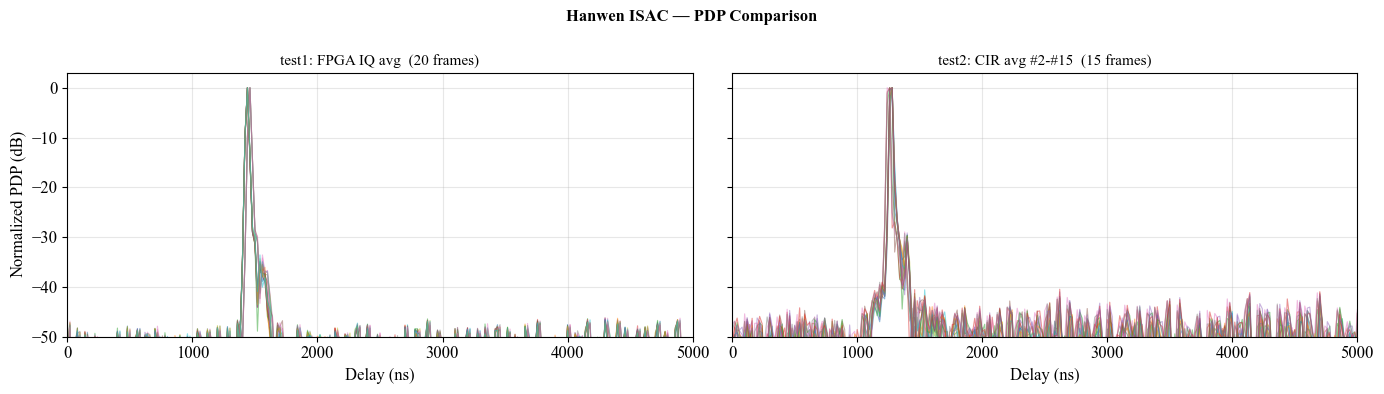

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

for i in range(n_frames1):
    pdp = np.abs(cir1[i]) ** 2
    pdp_db = 10 * np.log10(pdp + 1e-30)
    pdp_db -= pdp_db.max()
    axes[0].plot(delay_ns, pdp_db, lw=0.8, alpha=0.5)
axes[0].set_title(f'test1: FPGA IQ avg  ({n_frames1} frames)', fontsize=11)

for i in range(n_frames2):
    pdp = np.abs(cir2[i]) ** 2
    pdp_db = 10 * np.log10(pdp + 1e-30)
    pdp_db -= pdp_db.max()
    axes[1].plot(delay_ns, pdp_db, lw=0.8, alpha=0.5)
axes[1].set_title(f'test2: CIR avg #2-#15  ({n_frames2} frames)', fontsize=11)

for ax in axes:
    ax.set_xlabel('Delay (ns)')
    ax.set_xlim([0, 5000])
    ax.set_ylim([-50, 3])
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel('Normalized PDP (dB)')

fig.suptitle('Hanwen ISAC — PDP Comparison', fontsize=12, fontweight='bold')
fig.tight_layout()
plt.show()

## Section 6: test3 — FPGA 整数平均模拟（复现 `rt_aver_calc` 行为）

test2 的 Python 处理与 FPGA 实际处理存在两处差异，test3 逐一复现以便排除干扰：

| 差异项 | test2 (Python) | test3 (FPGA 模拟) |
|--------|---------------|-------------------|
| **除法方式** | 浮点 ÷ 14（精确，四舍五入） | 整数累加后 `>> 4`（÷16，截断）|
| **I/Q 处理** | 复数统一处理 | I/Q 分路，各例化一个 `rt_aver_calc` |
| **CIR 计算** | FFT + IFFT（`correlate_single`） | FFT + IFFT（相同，无差异）|

> **前置条件**：`iq2_all` 已在 Section 3 中加载。  
> `ACC_BITS = 4`（即 `ACC_BW`），对应窗口大小 $2^4 = 16$（FPGA 以移位代替除法）。

In [12]:
ACC_BITS = 4             # FPGA: data_in_acc >> ACC_BW，等价于 ÷16
IQ_SCALE = 32768.0       # int16 量化：浮点 × 32768 → int16 精度


def iq_avg_fpga(iq_frame: np.ndarray) -> np.ndarray:
    """模拟 rt_aver_calc 的 I/Q 分路整数平均。

    步骤（与 FPGA 逻辑对应）：
    1. 跳过 IQ#0，取 #1-#14（14 个）
    2. I/Q 分路，各量化为 int16 精度
    3. 整数累加（两路各用独立累加器）
    4. 算术右移 ACC_BITS 位截断（== FPGA: acc >> ACC_BW）
    5. 重组为 complex64

    参数
    -----
    iq_frame : (15, U) complex64，单帧 15 个 IQ 序列

    返回
    -----
    (U,) complex64，FPGA 风格整数平均结果
    """
    iq_sub = iq_frame[1:]   # (14, U)，跳过 IQ#0

    # 量化到 int16（模拟 FPGA ADC 整数格式）
    I_int = np.round(np.real(iq_sub) * IQ_SCALE).astype(np.int32)  # (14, U)
    Q_int = np.round(np.imag(iq_sub) * IQ_SCALE).astype(np.int32)

    # I/Q 分路各自独立累加（顶层例化两个 rt_aver_calc）
    I_acc = I_int.sum(axis=0).astype(np.int64)   # (U,)
    Q_acc = Q_int.sum(axis=0).astype(np.int64)

    # 算术右移截断（负数保符号位，与 Verilog >>> 一致）
    I_avg = I_acc >> ACC_BITS
    Q_avg = Q_acc >> ACC_BITS

    return ((I_avg + 1j * Q_avg) / IQ_SCALE).astype(np.complex64)


# 对每帧计算 FPGA 风格平均 IQ → FFT 匹配滤波 → CIR
cir3 = np.zeros((n_frames2, U), dtype=np.complex64)
for i in range(n_frames2):
    iq_fpga = iq_avg_fpga(iq2_all[i])    # (U,) complex64
    cir3[i] = correlate_single(iq_fpga)  # FFT 相关，与 test2 相同路径

print(f'test3 (FPGA模拟): {n_frames2} frames, CIR shape = {cir3.shape}')
print(f'ACC_BITS={ACC_BITS}  →  整数÷{2**ACC_BITS}（截断）  vs  浮点÷14（test2）')

test3 (FPGA模拟): 15 frames, CIR shape = (15, 1024)
ACC_BITS=4  →  整数÷16（截断）  vs  浮点÷14（test2）


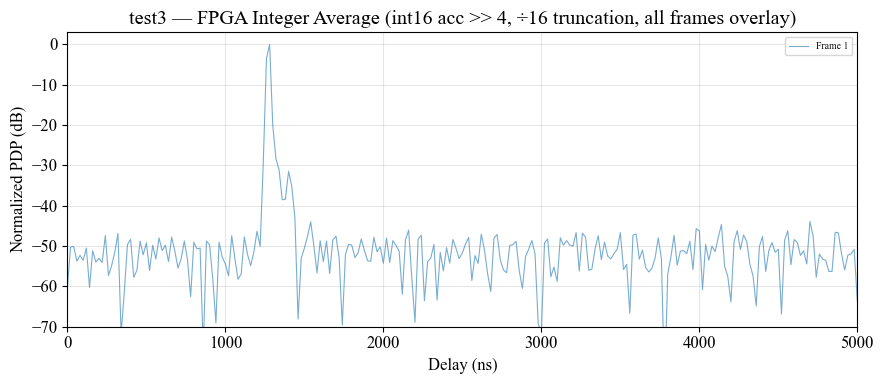

In [13]:
fig, ax = plt.subplots(figsize=(9, 4))
for i in [1]: # range(n_frames2)
    pdp = np.abs(cir3[i]) ** 2
    pdp_db = 10 * np.log10(pdp + 1e-30)
    pdp_db -= pdp_db.max()
    ax.plot(delay_ns, pdp_db, lw=0.8, alpha=0.6, label=f'Frame {i}')

ax.set_xlabel('Delay (ns)')
ax.set_ylabel('Normalized PDP (dB)')
ax.set_title(f'test3 — FPGA Integer Average (int16 acc >> {ACC_BITS}, ÷{2**ACC_BITS} truncation, all frames overlay)')
ax.set_xlim([0, 5000])
ax.set_ylim([-70, 3])
ax.grid(True, alpha=0.3)
if n_frames2 <= 20:
    ax.legend(fontsize=7, ncol=4, loc='upper right')
fig.tight_layout()
plt.show()

In [14]:
print(f'  Frame  Peak_bin  Peak_delay(ns)  SNR(dB)')
print('-' * 46)
for i in range(n_frames2):
    pdp = np.abs(cir3[i]) ** 2
    pb  = int(np.argmax(pdp))
    pd_ns = pb * 1e9 / BW_HZ
    mask = np.abs(np.arange(U) - pb) > 50
    nf   = np.median(pdp[mask]) if mask.sum() > 10 else pdp.min()
    snr  = 10 * np.log10(pdp[pb] / max(nf, 1e-30))
    print(f'  {i:5d}  {pb:8d}  {pd_ns:14.1f}  {snr:8.2f}')

  Frame  Peak_bin  Peak_delay(ns)  SNR(dB)
----------------------------------------------
      0        64          1280.0     53.11
      1        64          1280.0     52.52
      2        63          1260.0     52.17
      3        63          1260.0     50.95
      4        64          1280.0     51.28
      5        63          1260.0     50.57
      6        62          1240.0     50.83
      7        63          1260.0     50.96
      8        64          1280.0     51.77
      9        64          1280.0     51.90
     10        64          1280.0     51.71
     11        64          1280.0     51.51
     12        64          1280.0     50.74
     13        64          1280.0     50.70
     14        64          1280.0     50.92


### test2 vs test3 — PDP 对比（排查整数截断误差）

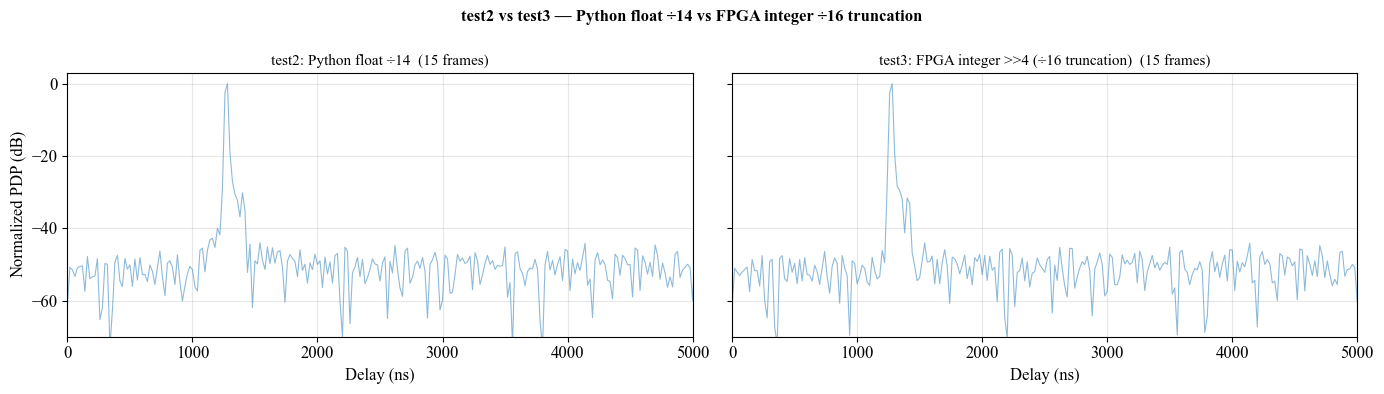


 Frame  test2 peak(ns)  test3 peak(ns)    dSNR(dB)
----------------------------------------------------
     0          1280.0          1280.0       -0.11
     1          1280.0          1280.0       -0.08
     2          1260.0          1260.0       -0.07
     3          1260.0          1260.0       -0.18
     4          1280.0          1280.0       -0.19
     5          1260.0          1260.0       -0.22
     6          1240.0          1240.0       -0.21
     7          1260.0          1260.0       -0.33
     8          1280.0          1280.0       -0.12
     9          1280.0          1280.0       -0.29
    10          1280.0          1280.0       -0.23
    11          1280.0          1280.0       -0.26
    12          1280.0          1280.0       -0.21
    13          1280.0          1280.0       -0.06
    14          1280.0          1280.0       -0.20


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

for i in [8]: # range(n_frames2)
    pdp = np.abs(cir2[i]) ** 2
    pdp_db = 10 * np.log10(pdp + 1e-30)
    pdp_db -= pdp_db.max()
    axes[0].plot(delay_ns, pdp_db, lw=0.8, alpha=0.5)
axes[0].set_title(f'test2: Python float ÷14  ({n_frames2} frames)', fontsize=11)

for i in [8]: # range(n_frames2)
    pdp = np.abs(cir3[i]) ** 2
    pdp_db = 10 * np.log10(pdp + 1e-30)
    pdp_db -= pdp_db.max()
    axes[1].plot(delay_ns, pdp_db, lw=0.8, alpha=0.5)
axes[1].set_title(f'test3: FPGA integer >>4 (÷16 truncation)  ({n_frames2} frames)', fontsize=11)

for ax in axes:
    ax.set_xlabel('Delay (ns)')
    ax.set_xlim([0, 5000])
    ax.set_ylim([-70, 3])
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel('Normalized PDP (dB)')

fig.suptitle('test2 vs test3 — Python float ÷14 vs FPGA integer ÷16 truncation', fontsize=12, fontweight='bold')
fig.tight_layout()
plt.show()

# Per-frame peak delay shift and SNR difference
print(f'\n{"Frame":>6}  {"test2 peak(ns)":>14}  {"test3 peak(ns)":>14}  {"dSNR(dB)":>10}')
print('-' * 52)
for i in range(n_frames2): #
    def _stats(cir):
        pdp = np.abs(cir) ** 2
        pb  = int(np.argmax(pdp))
        mask = np.abs(np.arange(U) - pb) > 50
        nf  = np.median(pdp[mask]) if mask.sum() > 10 else pdp.min()
        snr = 10 * np.log10(pdp[pb] / max(nf, 1e-30))
        return pb * 1e9 / BW_HZ, snr
    d2, s2 = _stats(cir2[i])
    d3, s3 = _stats(cir3[i])
    print(f'  {i:4d}  {d2:14.1f}  {d3:14.1f}  {s3-s2:10.2f}')

## Section 7: test1 / test2 / test3 — Main Path & Second Path Power vs Noise Floor

For each frame, compute:
- **Main path SNR** = peak power / noise floor (dB)
- **Second path SNR** = second peak power / noise floor (dB)

Noise floor estimated as median PDP over bins > 50 away from any peak.  
Second path: highest peak outside a ±30 bin exclusion zone around the main peak.

In [16]:
# Second path search window (relative to main peak bin)
SP_MIN =  3   # min offset right of main peak (bins)
SP_MAX = 40   # max offset right of main peak (bins)
# At 50 MHz: 1 bin = 20 ns  →  search window = [60 ns, 800 ns] after main peak

def path_snrs(cir_mat: np.ndarray):
    """Per-frame main-path SNR and second-path SNR (dB above noise floor).

    Second path: highest bin in [pb+SP_MIN, pb+SP_MAX] window (wall reflection).
    Returns (main_snr, sec_snr) arrays; sec_snr is NaN if no valid second peak.
    """
    n = cir_mat.shape[0]
    main_snr = np.zeros(n)
    sec_snr  = np.full(n, np.nan)

    for i in range(n):
        pdp = np.abs(cir_mat[i]) ** 2
        pb  = int(np.argmax(pdp))

        # Noise floor: median over bins far from main peak
        nf_mask = np.abs(np.arange(U) - pb) > 50
        nf = np.median(pdp[nf_mask]) if nf_mask.sum() > 10 else pdp.min()
        nf = max(nf, 1e-30)

        main_snr[i] = 10 * np.log10(pdp[pb] / nf)

        # Second path: fixed window right of main peak
        lo = min(pb + SP_MIN, U - 1)
        hi = min(pb + SP_MAX, U - 1)
        if hi > lo:
            sp_bin = lo + int(np.argmax(pdp[lo:hi]))
            if pdp[sp_bin] > nf:
                sec_snr[i] = 10 * np.log10(pdp[sp_bin] / nf)

    return main_snr, sec_snr


m1, s1 = path_snrs(cir1)
m2, s2 = path_snrs(cir2)
m3, s3 = path_snrs(cir3)

def fmt(arr):
    valid = arr[~np.isnan(arr)]
    return f'{valid.mean():6.2f} ± {valid.std():.2f}' if len(valid) else '     N/A'

print(f'Second-path search: main_peak + [{SP_MIN}, {SP_MAX}] bins'
      f'  ({SP_MIN*20}–{SP_MAX*20} ns after main peak)')
print()
print(f'{"":8s}  {"N":>4}  {"Main-path SNR (dB)":>22}  {"Second-path SNR (dB)":>24}')
print(f'{"":8s}  {"":>4}  {"mean ± std":>22}  {"mean ± std":>24}')
print('─' * 65)
for tag, m, s, n in [('test1', m1, s1, len(m1)),
                     ('test2', m2, s2, len(m2)),
                     ('test3', m3, s3, len(m3))]:
    print(f'{tag:8s}  {n:4d}  {fmt(m):>22}  {fmt(s):>24}')
print('─' * 65)
print()
print('Δ Main-path SNR')
print(f'  test1 − test2 : {m1.mean()-m2.mean():+.2f} dB')
print(f'  test1 − test3 : {m1.mean()-m3.mean():+.2f} dB')
print(f'  test2 − test3 : {m2.mean()-m3.mean():+.2f} dB')
s1v = s1[~np.isnan(s1)]; s2v = s2[~np.isnan(s2)]; s3v = s3[~np.isnan(s3)]
if len(s1v) and len(s2v) and len(s3v):
    print()
    print('Δ Second-path SNR')
    print(f'  test1 − test2 : {s1v.mean()-s2v.mean():+.2f} dB')
    print(f'  test1 − test3 : {s1v.mean()-s3v.mean():+.2f} dB')
    print(f'  test2 − test3 : {s2v.mean()-s3v.mean():+.2f} dB')

Second-path search: main_peak + [3, 40] bins  (60–800 ns after main peak)

             N      Main-path SNR (dB)      Second-path SNR (dB)
                            mean ± std                mean ± std
─────────────────────────────────────────────────────────────────
test1       20            53.96 ± 0.11              23.15 ± 0.57
test2       15            51.63 ± 0.70              21.71 ± 0.71
test3       15            51.44 ± 0.72              21.56 ± 0.37
─────────────────────────────────────────────────────────────────

Δ Main-path SNR
  test1 − test2 : +2.33 dB
  test1 − test3 : +2.51 dB
  test2 − test3 : +0.18 dB

Δ Second-path SNR
  test1 − test2 : +1.44 dB
  test1 − test3 : +1.59 dB
  test2 − test3 : +0.15 dB


/tmp/ipykernel_125916/2913011001.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([m for m in m_data], labels=labels, patch_artist=True,
/tmp/ipykernel_125916/2913011001.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(s_valid, labels=labels, patch_artist=True,


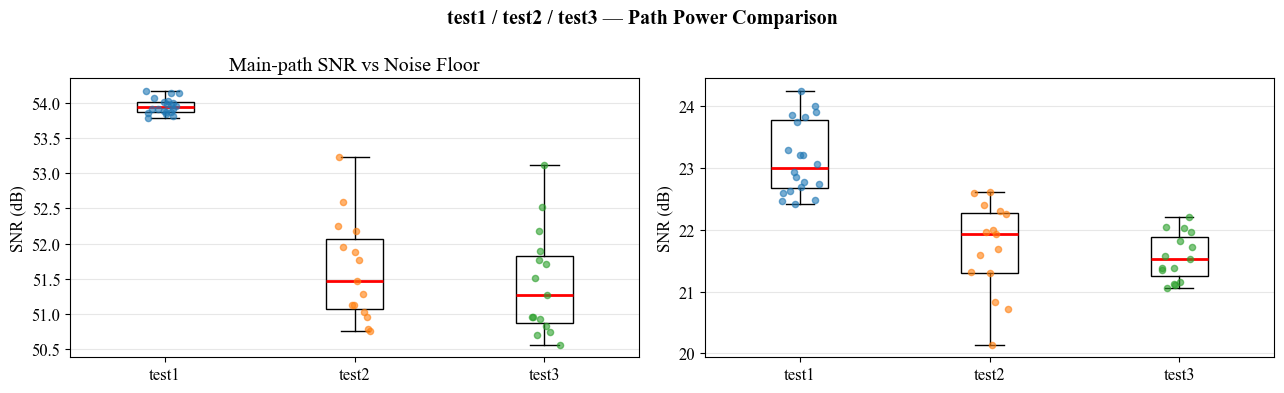

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

labels  = ['test1', 'test2', 'test3']
m_data  = [m1, m2, m3]
s_data  = [s1, s2, s3]
colors  = ['#1f77b4', '#ff7f0e', '#2ca02c']

# Main-path SNR box plot
ax = axes[0]
ax.boxplot([m for m in m_data], labels=labels, patch_artist=True,
           boxprops=dict(facecolor='none'),
           medianprops=dict(color='red', lw=2))
for i, (m, c) in enumerate(zip(m_data, colors), 1):
    ax.scatter(np.full(len(m), i) + np.random.uniform(-0.1, 0.1, len(m)),
               m, s=20, color=c, alpha=0.6, zorder=3)
ax.set_ylabel('SNR (dB)')
ax.set_title('Main-path SNR vs Noise Floor')
ax.grid(True, alpha=0.3, axis='y')

# Second-path SNR box plot
ax2 = axes[1]
s_valid = [sv[~np.isnan(sv)] for sv in s_data]
ax2.boxplot(s_valid, labels=labels, patch_artist=True,
            boxprops=dict(facecolor='none'),
            medianprops=dict(color='red', lw=2))
for i, (sv, c) in enumerate(zip(s_valid, colors), 1):
    if len(sv):
        ax2.scatter(np.full(len(sv), i) + np.random.uniform(-0.1, 0.1, len(sv)),
                    sv, s=20, color=c, alpha=0.6, zorder=3)
ax2.set_ylabel('SNR (dB)')
ax2.grid(True, alpha=0.3, axis='y')

fig.suptitle('test1 / test2 / test3 — Path Power Comparison', fontweight='bold')
fig.tight_layout()
plt.show()

## Section 8: test4 — FPGA CIR 域平均模拟（逐 IQ FFT/IFFT → CIR 平均）

**三种平均方式对比**

| | test2 | test3 | test4 |
|---|---|---|---|
| **平均域** | CIR 域（滑动相关） | **IQ 域** | **CIR 域** |
| **量化** | 浮点 ÷14 | int16 输入 + >>4 | int16 输入 + CIR 整数平均 >>4 |
| **SNR 理论** | 基准 | ≈基准（coherent IQ 平均最优） | ≤基准（CFO 相位旋转可能相消） |

FPGA 16 位模拟策略：
- 输入 IQ 量化为 **int16**（模拟 ADC）
- FFT / IFFT 用浮点精度（Xilinx DSP48 内部 > 40 位，误差可忽略）
- 得到的 CIR 量化为 **int16**，整数累加，右移 4 位（÷16）取平均


In [19]:
import math

IQ_SCALE   = 32768.0        # ADC：int16 归一化因子（Q1.15 格式）
CIR_SCALE  = 32768.0        # CIR 存储 scale（CIR 幅度约 0.03，×32768≈942，在 int16 范围内）
CIR_AVG_BITS = 4            # CIR 域累加后右移位数 (÷16)


def _q16(x: np.ndarray, scale: float) -> np.ndarray:
    """将复数数组量化到 int16 精度（截断 + clip），返回 float64 (整数值)."""
    I = np.clip(np.round(np.real(x) * scale), -32768, 32767)
    Q = np.clip(np.round(np.imag(x) * scale), -32768, 32767)
    return I + 1j * Q   # 以整数值形式返回（未除以 scale）


def fpga_correlate_16b(iq_u: np.ndarray) -> np.ndarray:
    """单 IQ 块 → CIR，模拟 FPGA 16 位定点处理.

    步骤：
      1. 输入 IQ 量化到 int16（ADC 精度）
      2. DC 去除（整数减法）
      3. tile×3，FFT（浮点，模拟 Xilinx DSP 高精度内部计算）
      4. 乘匹配滤波器（浮点），IFFT
      5. CIR 输出量化到 int16（存储精度）
    """
    # Step 1-2: 输入量化 + DC 去除
    I_in = np.clip(np.round(np.real(iq_u) * IQ_SCALE), -32768, 32767).astype(np.int32)
    Q_in = np.clip(np.round(np.imag(iq_u) * IQ_SCALE), -32768, 32767).astype(np.int32)
    dc_I = int(round(I_in.mean()))
    dc_Q = int(round(Q_in.mean()))
    x_int = (I_in - dc_I) + 1j * (Q_in - dc_Q)   # int32，DC 去除

    # Step 3-4: tile×3，FFT × 匹配滤波器，IFFT（全浮点，模拟高精度 DSP）
    ext   = np.tile(x_int.astype(np.complex128), 3)
    X     = np.fft.fft(ext, n=_N_FFT)
    S_f   = np.fft.fft(_S_MATCHED.astype(np.complex128), n=_N_FFT)
    cir_raw = np.fft.ifft(X * S_f)[2 * U - 1 : 3 * U - 1]  # (U,)
    cir_fp  = (cir_raw / (U * IQ_SCALE)).astype(np.complex64)  # 归一化到浮点

    # Step 5: CIR 量化到 int16 存储
    cir_I = np.clip(np.round(np.real(cir_fp) * CIR_SCALE), -32768, 32767).astype(np.int16)
    cir_Q = np.clip(np.round(np.imag(cir_fp) * CIR_SCALE), -32768, 32767).astype(np.int16)
    return cir_I.astype(np.float32) / CIR_SCALE + 1j * cir_Q.astype(np.float32) / CIR_SCALE


# 验证函数正确性（与浮点基准对比）
_iq_test = iq2_all[0, 1]   # 取第 0 帧第 1 个 IQ 作测试
_cir_fp  = correlate_single(_iq_test)
_cir_16b = fpga_correlate_16b(_iq_test)
print(f'CIR 幅度：float={np.abs(_cir_fp).max():.5f}  16b={np.abs(_cir_16b).max():.5f}')
print(f'RMSE(float vs 16b) = {np.sqrt(np.mean(np.abs(_cir_fp - _cir_16b)**2)):.2e}')
print(f'→ 16 bit 量化误差（int16 粒度 1/32768 ≈ 3e-5）正常')


CIR 幅度：float=0.02874  16b=0.02874
RMSE(float vs 16b) = 1.25e-05
→ 16 bit 量化误差（int16 粒度 1/32768 ≈ 3e-5）正常


In [20]:
SKIP_FIRST = True   # 跳过 IQ#0（与 test2/test3 保持一致）

cir4_fp  = np.zeros((n_frames2, U), dtype=np.complex64)   # test4a：浮点基准
cir4_16b = np.zeros((n_frames2, U), dtype=np.complex64)   # test4b：16 位定点

for frm in range(n_frames2):
    iq_frame = iq2_all[frm]                                    # (15, U)
    idx = list(range(1, 15)) if SKIP_FIRST else list(range(15))
    n_avg = len(idx)

    # ── test4a：逐 IQ 浮点相关 → 浮点 CIR 平均 ────────────────────────────
    cirs_fp = np.stack([correlate_single(iq_frame[i]) for i in idx])
    cir4_fp[frm] = cirs_fp.mean(axis=0)

    # ── test4b：逐 IQ 16 位相关 → int16 CIR 整数累加 → >>4 平均 ───────────
    acc_I = np.zeros(U, dtype=np.int32)
    acc_Q = np.zeros(U, dtype=np.int32)
    for i in idx:
        cir_q = fpga_correlate_16b(iq_frame[i])
        acc_I += np.round(np.real(cir_q) * CIR_SCALE).astype(np.int32)
        acc_Q += np.round(np.imag(cir_q) * CIR_SCALE).astype(np.int32)
    cir4_16b[frm] = ((acc_I >> CIR_AVG_BITS) + 1j * (acc_Q >> CIR_AVG_BITS)) / CIR_SCALE

print(f'test4 计算完成: {n_frames2} 帧，每帧 {n_avg} 个 IQ（SKIP_FIRST={SKIP_FIRST}）')


test4 计算完成: 15 帧，每帧 14 个 IQ（SKIP_FIRST=True）


In [21]:
def get_snrs(cir_mat, label):
    snrs, pds = [], []
    for i in range(cir_mat.shape[0]):
        pdp  = np.abs(cir_mat[i]) ** 2
        pb   = int(np.argmax(pdp))
        mask = np.abs(np.arange(U) - pb) > 50
        nf   = np.median(pdp[mask]) if mask.sum() > 10 else pdp.min()
        snrs.append(10 * np.log10(pdp[pb] / max(nf, 1e-30)))
        pds.append(pb * 1e9 / BW_HZ)
    snrs, pds = np.array(snrs), np.array(pds)
    print(f'{label}')
    print(f'  peak delay = {pds.mean():.1f} ± {pds.std():.1f} ns')
    print(f'  SNR        = {snrs.mean():.2f} ± {snrs.std():.2f} dB')
    return snrs

print('=' * 58)
s2   = get_snrs(cir2,     'test2   Python float 滑动相关 ÷14')
s3   = get_snrs(cir3,     'test3   FPGA IQ域平均 int16 >>4')
s4fp = get_snrs(cir4_fp,  'test4a  FPGA CIR域平均 浮点基准')
s4q  = get_snrs(cir4_16b, 'test4b  FPGA CIR域平均 16位定点')
print('=' * 58)
print(f'Δ SNR  test2 − test4a (算法差异)     = {s2.mean()-s4fp.mean():+.3f} dB')
print(f'Δ SNR  test4a − test4b (量化损失)    = {s4fp.mean()-s4q.mean():+.3f} dB')
print(f'Δ SNR  test2 − test4b (总差异)       = {s2.mean()-s4q.mean():+.3f} dB')
print(f'Δ SNR  test3 − test4b (IQ域 vs CIR域) = {s3.mean()-s4q.mean():+.3f} dB')


test2   Python float 滑动相关 ÷14
  peak delay = 1272.0 ± 12.2 ns
  SNR        = 51.63 ± 0.70 dB
test3   FPGA IQ域平均 int16 >>4
  peak delay = 1272.0 ± 12.2 ns
  SNR        = 51.44 ± 0.72 dB
test4a  FPGA CIR域平均 浮点基准
  peak delay = 1272.0 ± 12.2 ns
  SNR        = 51.45 ± 0.73 dB
test4b  FPGA CIR域平均 16位定点
  peak delay = 1272.0 ± 12.2 ns
  SNR        = 49.79 ± 1.38 dB
Δ SNR  test2 − test4a (算法差异)     = +0.175 dB
Δ SNR  test4a − test4b (量化损失)    = +1.659 dB
Δ SNR  test2 − test4b (总差异)       = +1.834 dB
Δ SNR  test3 − test4b (IQ域 vs CIR域) = +1.652 dB


/tmp/ipykernel_125916/1702729136.py:35: UserWarning: Glyph 28369 (\N{CJK UNIFIED IDEOGRAPH-6ED1}) missing from font(s) Times New Roman.
  fig.tight_layout()
/tmp/ipykernel_125916/1702729136.py:35: UserWarning: Glyph 21160 (\N{CJK UNIFIED IDEOGRAPH-52A8}) missing from font(s) Times New Roman.
  fig.tight_layout()
/tmp/ipykernel_125916/1702729136.py:35: UserWarning: Glyph 30456 (\N{CJK UNIFIED IDEOGRAPH-76F8}) missing from font(s) Times New Roman.
  fig.tight_layout()
/tmp/ipykernel_125916/1702729136.py:35: UserWarning: Glyph 20851 (\N{CJK UNIFIED IDEOGRAPH-5173}) missing from font(s) Times New Roman.
  fig.tight_layout()
/tmp/ipykernel_125916/1702729136.py:35: UserWarning: Glyph 22495 (\N{CJK UNIFIED IDEOGRAPH-57DF}) missing from font(s) Times New Roman.
  fig.tight_layout()
/tmp/ipykernel_125916/1702729136.py:35: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) Times New Roman.
  fig.tight_layout()
/tmp/ipykernel_125916/1702729136.py:35: UserWarning: Glyph

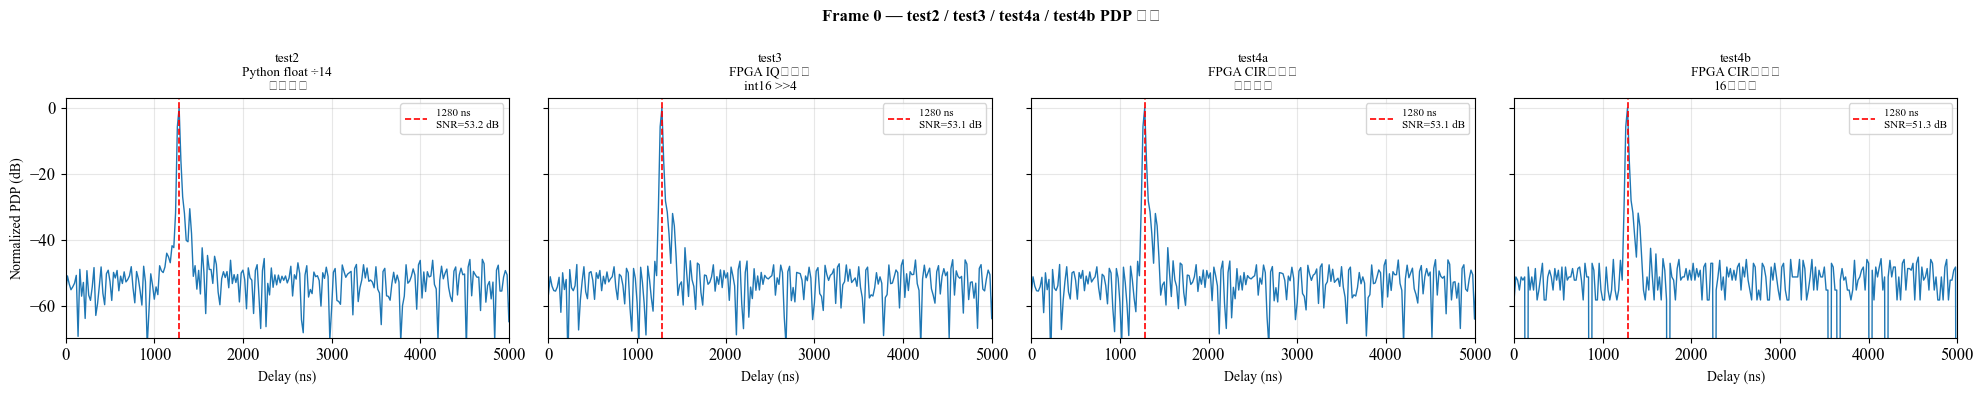

In [22]:
FRAME_SHOW = 0

fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=True)
pairs = [
    (cir2,     'test2\nPython float ÷14\n滑动相关'),
    (cir3,     'test3\nFPGA IQ域平均\nint16 >>4'),
    (cir4_fp,  'test4a\nFPGA CIR域平均\n浮点基准'),
    (cir4_16b, 'test4b\nFPGA CIR域平均\n16位定点'),
]

for ax, (cir_mat, title) in zip(axes, pairs):
    cir    = cir_mat[FRAME_SHOW]
    pdp    = np.abs(cir) ** 2
    pdp_db = 10 * np.log10(pdp + 1e-30)
    pdp_db -= pdp_db.max()
    pb     = int(np.argmax(pdp))
    pd_ns  = pb * 1e9 / BW_HZ
    mask   = np.abs(np.arange(U) - pb) > 50
    nf     = np.median(pdp[mask]) if mask.sum() > 10 else pdp.min()
    snr    = 10 * np.log10(pdp[pb] / max(nf, 1e-30))

    ax.plot(delay_ns, pdp_db, lw=1)
    ax.axvline(pd_ns, color='r', ls='--', lw=1.2,
               label=f'{pd_ns:.0f} ns\nSNR={snr:.1f} dB')
    ax.set_title(title, fontsize=9.5)
    ax.set_xlabel('Delay (ns)', fontsize=10)
    ax.set_xlim([0, 5000])
    ax.set_ylim([-70, 3])
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Normalized PDP (dB)', fontsize=10)
fig.suptitle(f'Frame {FRAME_SHOW} — test2 / test3 / test4a / test4b PDP 对比',
             fontsize=12, fontweight='bold')
fig.tight_layout()
plt.show()


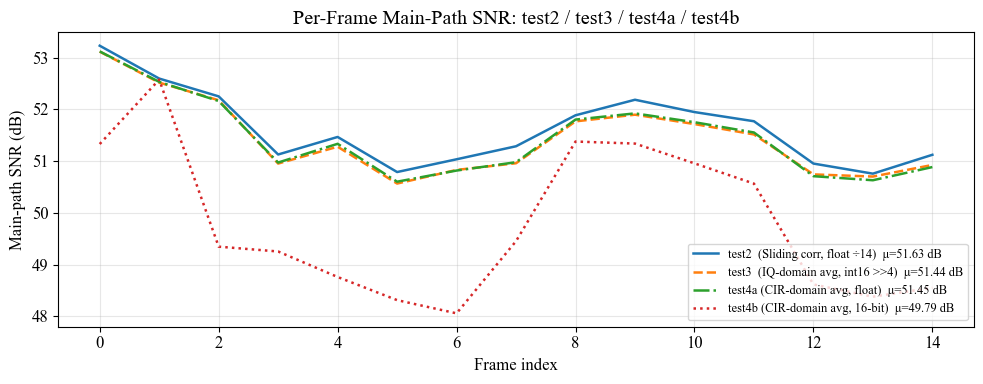

In [24]:
def frame_snrs(cir_mat):
    snrs = []
    for i in range(cir_mat.shape[0]):
        pdp  = np.abs(cir_mat[i]) ** 2
        pb   = int(np.argmax(pdp))
        mask = np.abs(np.arange(U) - pb) > 50
        nf   = np.median(pdp[mask]) if mask.sum() > 10 else pdp.min()
        snrs.append(10 * np.log10(pdp[pb] / max(nf, 1e-30)))
    return np.array(snrs)

frames = np.arange(n_frames2)
fig, ax = plt.subplots(figsize=(10, 4))

for cir_mat, lbl, ls, col in [
    (cir2,     'test2  (Sliding corr, float ÷14)',  '-',  '#1f77b4'),
    (cir3,     'test3  (IQ-domain avg, int16 >>4)', '--', '#ff7f0e'),
    (cir4_fp,  'test4a (CIR-domain avg, float)',    '-.', '#2ca02c'),
    (cir4_16b, 'test4b (CIR-domain avg, 16-bit)',   ':',  '#d62728'),
]:
    snrs = frame_snrs(cir_mat)
    ax.plot(frames, snrs, ls=ls, lw=1.8, color=col,
            label=f'{lbl}  μ={snrs.mean():.2f} dB')

ax.set_xlabel('Frame index')
ax.set_ylabel('Main-path SNR (dB)')
ax.set_title('Per-Frame Main-Path SNR: test2 / test3 / test4a / test4b')
ax.legend(fontsize=9, loc='lower right')
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()
